In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plot
import numpy as np
from sklearn.linear_model import LinearRegression

from sqlalchemy import engine
from pandasql import sqldf
pysqldf= lambda q: sqldf(q, globals())

In [2]:
df=pd.read_csv("bc_completo.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   periodo              19 non-null     int64  
 1   tasa_neta_ocupacion  19 non-null     float64
 2   tipo_cambio          19 non-null     float64
 3   variacion            19 non-null     float64
 4   indpro               19 non-null     float64
 5   ied_bc               19 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 1.0 KB


In [4]:
df

,periodo,tasa_neta_ocupacion,tipo_cambio,variacion,indpro,ied_bc
0,2006,75.606421,10.903372,-1.027659,98.995317,1340.691610
1,2007,75.325659,10.927441,-0.280762,101.571992,1790.829226
2,2008,74.358605,11.143810,-0.967054,98.117275,1454.140673
3,2009,70.987078,13.498305,-3.371526,86.899625,829.523190
4,2010,70.225831,12.628694,-0.761247,91.737033,1414.822950
5,2011,70.538321,12.430060,0.312489,94.639558,766.322327
6,2012,69.778694,13.168949,-0.759627,97.540858,1018.518951
7,2013,72.095495,12.769568,2.316801,99.484375,1290.826481
8,2014,71.501733,13.303180,-0.593762,102.447650,1223.344367
9,2015,72.919265,15.881004,1.417532,100.971950,1167.278445


In [6]:
# Matriz de correlación completa
print("\nCorrelaciones con tasa de ocupación:")
corr = df[["tasa_neta_ocupacion", "tipo_cambio", "indpro", "ied_bc"]].corr()
print(corr["tasa_neta_ocupacion"].round(3))


Correlaciones con tasa de ocupación:
tasa_neta_ocupacion    1.000
tipo_cambio            0.062
indpro                 0.575
ied_bc                 0.389
Name: tasa_neta_ocupacion, dtype: float64


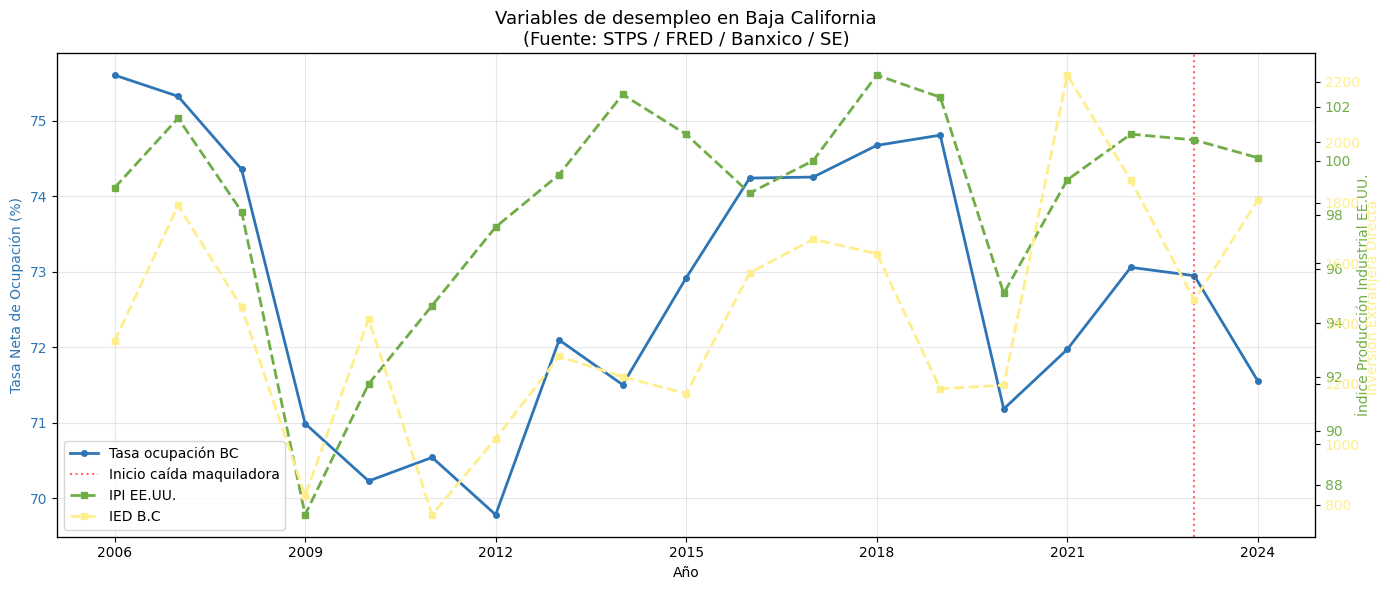


Correlaciones con tasa de ocupación:
tasa_neta_ocupacion    1.00000
tipo_cambio            0.06166
indpro                 0.57514
ied_bc                 0.38930
Name: tasa_neta_ocupacion, dtype: float64


In [8]:
# Gráfica triple
fig, ax1 = plot.subplots(figsize=(14, 6))

ax1.plot(df["periodo"], df["tasa_neta_ocupacion"],
         color="#2E75B6", linewidth=2, marker="o", markersize=4, label="Tasa ocupación BC")
ax1.set_ylabel("Tasa Neta de Ocupación (%)", color="#2E75B6")
ax1.tick_params(axis="y", labelcolor="#2E75B6")
ax1.set_xticks(range(int(df["periodo"].min()), int(df["periodo"].max())+1, 3))

ax2 = ax1.twinx()
ax2.plot(df["periodo"], df["indpro"],
         color="#70AD47", linewidth=2, linestyle="--", marker="s", markersize=4, label="IPI EE.UU.")
ax2.set_ylabel("Índice Producción Industrial EE.UU.", color="#70AD47")
ax2.tick_params(axis="y", labelcolor="#70AD47")

ax3= ax1.twinx()
ax3.plot(df["periodo"], df["ied_bc"],
         color="#FFEE8C", linewidth=2, linestyle="--", marker="s", markersize=4, label="IED B.C")
ax3.set_ylabel("Inversión Extranjera Directa ", color="#FFEE8C")
ax3.tick_params(axis="y", labelcolor="#FFEE8C")



ax1.axvline(2023, color="red", linestyle=":", alpha=0.6, label="Inicio caída maquiladora")
ax1.set_title("Variables de desempleo en Baja California\n(Fuente: STPS / FRED / Banxico / SE)", fontsize=13)
ax1.set_xlabel("Año")
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

ax1.legend(lines1 + lines2 + lines3 , labels1 + labels2 + labels3 , loc="lower left")

plot.tight_layout()
plot.show()

# Matriz de correlación completa
print("\nCorrelaciones con tasa de ocupación:")
corr = df[["tasa_neta_ocupacion", "tipo_cambio", "indpro", "ied_bc"]].corr()
print(corr["tasa_neta_ocupacion"].round(5))

In [10]:
#Coeficientes y R2
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

# Preparar variables
X = df[["indpro", "ied_bc", "tipo_cambio", ]].dropna()
y = df.loc[X.index, "tasa_neta_ocupacion"]

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modelo
modelo = LinearRegression()
modelo.fit(X_scaled, y)

print(f"R² del modelo: {modelo.score(X_scaled, y):.3f}")
print("\nCoeficientes (importancia de cada variable):")
for var, coef in zip(X.columns, modelo.coef_):
    print(f"  {var}: {coef:.4f}")

R² del modelo: 0.370

Coeficientes (importancia de cada variable):
  indpro: 0.9227
  ied_bc: 0.3674
  tipo_cambio: -0.3031


In [12]:
#Interpretación de los resultados
print("\nInterpretación de los resultados:")
print("El modelo de regresión lineal múltiple muestra cómo las variables independientes (indpro, ied_bc, tipo_cambio) \nafectan la tasa neta de ocupación en Baja California.")
print("El R² indica qué proporción de la variabilidad en la tasa de ocupación puede explicarse por estas variables.")


Interpretación de los resultados:
El modelo de regresión lineal múltiple muestra cómo las variables independientes (indpro, ied_bc, tipo_cambio) 
afectan la tasa neta de ocupación en Baja California.
El R² indica qué proporción de la variabilidad en la tasa de ocupación puede explicarse por estas variables.
